From https://eloy.readthedocs.io/en/latest/photometry/

In [27]:

from astropy.io import fits
from dateutil import parser
from glob import glob

reference_file = "output/stack_image.fits"

#images = glob("data/*.fits.fz")
images = glob("/home/adamarthurryan/Desktop/baron obs/3c371/3c371_20260615_baron_ip/*.fits.fz")

target_name = "3C 371"

# get observation time from FITS header (SCI extension)
def observation_time(file):

    sci_header = fits.getheader(file, extname='sci')
    date_str = sci_header["DATE-OBS"]
    return parser.parse(date_str)


# order by observation time
images = sorted(images, key=lambda file: observation_time(file))


In [ ]:
#images=images[0:10]


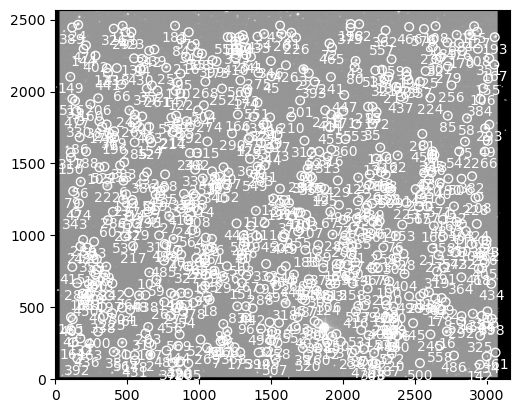

In [30]:
# calibration sequence

import numpy as np
import matplotlib.pyplot as plt
# from eloy import alignment, viz
# from eloy import psf, detection, utils

# --- vanilla photutils / astropy / twirl replacements for the eloy imports above ---
from astropy.stats import sigma_clipped_stats
from astropy.nddata import NDData
from astropy.table import Table
from astropy.visualization import ZScaleInterval
from photutils.segmentation import detect_sources, SourceCatalog
from photutils.psf import extract_stars, fit_2dgaussian
from photutils.aperture import CircularAperture

# photutils has no frame-to-frame star-pattern matching/registration, so
# alignment still relies on twirl directly (the library eloy itself wraps),
# rather than on eloy.
from scipy.spatial import cKDTree
from twirl import quads
from twirl.geometry import get_transform_matrix, pad
from twirl.match import count_cross_match


def z_scale(data, c=0.05):
    # replaces eloy.viz.z_scale, which was itself a thin wrapper around
    # astropy's ZScaleInterval
    return ZScaleInterval(contrast=c)(data.copy())


def plot_marks(coords, ax=None, color="w", ms=30, labels=None):
    # replaces eloy.viz.plot_marks: draw circular marks with photutils'
    # own aperture plotting instead of eloy's hand-rolled patches
    coords = np.atleast_2d(coords)
    if ax is None:
        ax = plt.gca()
    CircularAperture(coords, r=ms).plot(ax=ax, color=color)
    if labels is not None:
        for (x, y), label in zip(coords, labels):
            ax.annotate(str(label), (x, y - ms - 7), color=color, ha="center", va="top")


def stars_detection(image, threshold=5, npixels=25):
    # replaces eloy.detection.stars_detection: photutils image segmentation
    # instead of skimage thresholding/binary_opening
    _, median, std = sigma_clipped_stats(image, sigma=3.0)
    segment_image = detect_sources(image, median + threshold * std, npixels=npixels)
    return SourceCatalog(image, segment_image)


def get_cutouts(data, coords, size=51):
    # replaces eloy.utils.cutout for the ePSF use case below: photutils
    # provides its own star-cutout extractor, built for exactly this purpose
    nddata = NDData(data=data)
    stars_tbl = Table({"x": coords[:, 0], "y": coords[:, 1]})
    stars = extract_stars(nddata, stars_tbl, size=size)
    return np.array([s.data for s in stars])


def twirl_reference(coords):
    # replaces eloy.alignment.twirl_reference (a thin wrapper around twirl)
    quads_ref, asterisms_ref = quads.hashes(coords)
    tree_ref = cKDTree(quads_ref)
    return tree_ref, asterisms_ref


def cross_match(S1, S2, tolerance=10, return_idxs=False, none=True):
    # replaces eloy.alignment.cross_match, needed by rotation_matrix below
    s1 = S1.copy()
    s2 = S2.copy()

    s1[np.any(np.isnan(s1), 1)] = (1e15, 1e15)
    s2[np.any(np.isnan(s2), 1)] = (1e15, 1e15)

    matches = []
    for i, s in enumerate(s1):
        distances = np.linalg.norm(s - s2, axis=1)
        closest = np.argmin(distances)
        if distances[closest] < tolerance:
            matches.append([i, closest])
        else:
            if none:
                matches.append([i, np.nan])

    matches = np.array(matches)
    matches = matches[np.all(~np.isnan(matches), 1)]
    matches = matches.astype(int)

    if return_idxs:
        return matches
    else:
        if len(matches) > 0:
            return s1[matches[:, 0]], s2[matches[:, 1]]
        else:
            return np.array([]), np.array([])


def rotation_matrix(coords, ref_coords, reference, tolerance=2, refine=True, rtol=0.02):
    # replaces eloy.alignment.rotation_matrix (a thin wrapper around twirl)
    tree_ref, asterisms_ref = reference
    quads_image, asterisms_image = quads.hashes(coords)
    tree_image = cKDTree(quads_image)
    min_match = 0.7

    ball_query = tree_image.query_ball_tree(tree_ref, r=rtol)
    pairs = []
    for i, j in enumerate(ball_query):
        if len(j) > 0:
            pairs += [[i, k] for k in j]

    matches = []
    for i, j in pairs:
        M = get_transform_matrix(asterisms_ref[j], asterisms_image[i])
        test = (M @ pad(ref_coords).T)[0:2].T
        match = count_cross_match(coords, test, tolerance)
        matches.append(match)

        if min_match is not None:
            if isinstance(min_match, float):
                if match >= min_match * len(coords):
                    break

    if len(matches) == 0:
        return None
    else:
        i, j = pairs[np.argmax(matches)]
        if refine:
            M = get_transform_matrix(asterisms_ref[j], asterisms_image[i])
            test = (M @ pad(ref_coords).T)[0:2].T
            s1, s2 = cross_match(coords, test, tolerance=tolerance, return_idxs=True).T
            M = get_transform_matrix(ref_coords[s2], coords[s1])
        else:
            M = get_transform_matrix(asterisms_ref[j], asterisms_image[i])

        return M


trim = 10
n_stars_align = 12


def calibration_sequence(file):
    # getting data
    data = fits.getdata(file)
    header = fits.getheader(file)

    # trimming
    calibrated_data = data[trim:-trim, trim:-trim]
#    calibrated_data = data

    # detection
    # regions = detection.stars_detection(calibrated_data)
    catalog = stars_detection(calibrated_data)
    # stars coords and cutouts
    # region_coords = np.array([(r.centroid[1], r.centroid[0]) for r in regions])
    order = np.argsort(catalog.max_value)[::-1]
    region_coords = np.asarray(catalog.centroid)[order]
    # cutouts = utils.cutout(calibrated_data, region_coords, (50, 50))
    cutouts = get_cutouts(calibrated_data, region_coords, size=51)

    # epsf modeling
    cutouts_normalized = cutouts / np.nanmax(cutouts, (1, 2))[:, None, None]
    epsf = np.nanmedian(cutouts_normalized, 0)

    # psf_params = psf.fit_gaussian(epsf)
    # fwhm = psf.gaussian_sigma_to_fwhm * np.mean(
    #     [psf_params["sigma_x"], psf_params["sigma_y"]]
    # )
    psf_fit = fit_2dgaussian(epsf - np.nanmedian(epsf), fix_fwhm=False)
    fwhm = psf_fit.results["fwhm_fit"][0]

    del (
        cutouts_normalized,
        data,
        catalog,
        cutouts,
        epsf,
        header,
    )

    return calibrated_data, region_coords, fwhm


# and create a calibration sequence from the reference image

ref_data, ref_coords, ref_fwhm = calibration_sequence(reference_file)

#soft trim the reference coords to avoid edge effects in the alignment
soft_trim = 100
minx = soft_trim
maxx = ref_data.shape[1] - soft_trim
miny = soft_trim
maxy = ref_data.shape[0] - soft_trim
ref_coords = ref_coords[(ref_coords[:, 0]>minx) & (ref_coords[:, 0]<maxx) & (ref_coords[:, 1]>miny) & (ref_coords[:, 1]<maxy)]

# ref_reference = alignment.twirl_reference(ref_coords[0:n_stars_align])
ref_reference = twirl_reference(ref_coords[0:n_stars_align])

ref_header = fits.getheader(reference_file)

# plt.imshow(viz.z_scale(ref_data), cmap="Greys_r", origin="lower")
# viz.plot_marks(*ref_coords.T, color="w", label=True, ms=30)
plt.imshow(z_scale(ref_data), cmap="Greys_r", origin="lower")
plot_marks(ref_coords, color="w", ms=30, labels=range(len(ref_coords)))




In [17]:


rcT = ref_coords.T
print(rcT.shape)
print(rcT[0].shape)
print(ref_coords.shape)
print(ref_coords_temp.shape)


(2, 646)
(646,)
(646, 2)
(634, 2)


In [31]:
# now do the photometry sequence for all images

from tqdm.auto import tqdm
from skimage.transform import AffineTransform, warp
# from eloy.ballet import Ballet
from astropy.time import Time
from collections import defaultdict
# from eloy import centroid, photometry

# --- vanilla photutils replacements for the eloy imports above ---
from photutils.centroids import centroid_sources, centroid_quadratic
from photutils.aperture import (
    aperture_photometry as _photutils_aperture_photometry,
    CircularAperture,
    CircularAnnulus,
)
from astropy.stats import sigma_clipped_stats as _sigma_clipped_stats


def centroid_stars(data, coords, box_size=21):
    # replaces eloy.centroid.ballet_centroid: eloy's CNN-based centroider
    # (Ballet) has no photutils equivalent, so we fall back to the
    # quadratic-fit centroiding that eloy itself offers as a thin photutils
    # wrapper (eloy.centroid.photutils_centroid)
    x, y = coords.T
    xc, yc = centroid_sources(
        data, x, y, box_size=box_size, centroid_func=centroid_quadratic
    )
    centroid_coords = np.array([xc, yc]).T
    bad = ~np.all(np.isfinite(centroid_coords), axis=1)
    centroid_coords[bad] = coords[bad]
    return centroid_coords


def aperture_photometry(data, coords, radii, mask=None):
    # replaces eloy.photometry.aperture_photometry (a thin photutils
    # wrapper) - call photutils directly
    apertures = [CircularAperture(coords, r=r) for r in radii]
    return np.array(
        [
            _photutils_aperture_photometry(data, a, mask=mask)["aperture_sum"].data
            for a in apertures
        ]
    ).T


def annulus_sigma_clip_median(data, coords, r_in, r_out, sigma=3):
    # replaces eloy.photometry.annulus_sigma_clip_median (also a thin
    # photutils wrapper) - call photutils directly
    annulus = CircularAnnulus(coords, r_in, r_out)
    bkg_median = []
    for mask in annulus.to_mask(method="center"):
        annulus_data = mask.multiply(data)
        if annulus_data is not None:
            annulus_data_1d = annulus_data[mask.data > 0]
            _, median, _ = _sigma_clipped_stats(annulus_data_1d, sigma=sigma)
            bkg_median.append(median)
        else:
            bkg_median.append(0.0)
    return np.array(bkg_median)


n_stars = 100
relative_apertures_radii = np.linspace(0.1, 5, 40)
# cnn = Ballet()

data = defaultdict(list)

for file in tqdm(images):
    calibrated_data, coords, fwhm = calibration_sequence(file)

    # alignment
    # R = alignment.rotation_matrix(coords[0:n_stars_align], ref_coords, ref_reference)
    R = rotation_matrix(coords[0:n_stars_align], ref_coords, ref_reference)
    transform = AffineTransform(R)#.inverse
    aligned_coords = transform(ref_coords)[0:n_stars]
    dx, dy = np.median(ref_coords[0:n_stars] - aligned_coords, 0)

    # centroiding
    # centroid_coords = centroid.ballet_centroid(calibrated_data, aligned_coords, cnn)
    centroid_coords = centroid_stars(calibrated_data, aligned_coords)
    # aperture photometry
    apertures_radii = relative_apertures_radii * fwhm
    flux = aperture_photometry(
        calibrated_data, centroid_coords, apertures_radii
    )
    # annulus background correction
    annulus_radii = np.max(apertures_radii), 8 * fwhm
    aperture_area = np.pi * apertures_radii**2
    bkg = annulus_sigma_clip_median(
        calibrated_data, centroid_coords, *annulus_radii
    )
    bkg = bkg[:, None] * aperture_area[None, :]

    # getting data
    header = fits.open(file)[0].header
    data["bkg"].append(bkg)
    data["fluxes"].append(flux)
    data["fwhm"].append(fwhm)
    
    sci_header = fits.getheader(file, extname='sci')
    date_str = sci_header["DATE-OBS"]
    jd = Time(parser.parse(date_str)).jd


    #jd = Time(parser.parse(header["DATE-OBS"])).jd
    data["time"].append(jd)
    data["dx"].append(dx)
    data["dy"].append(dy)


for k, v in data.items():
    data[k] = np.array(v)


  0%|          | 0/97 [00:00<?, ?it/s]

In [7]:
data["fluxes"].shape

(10, 100, 40)

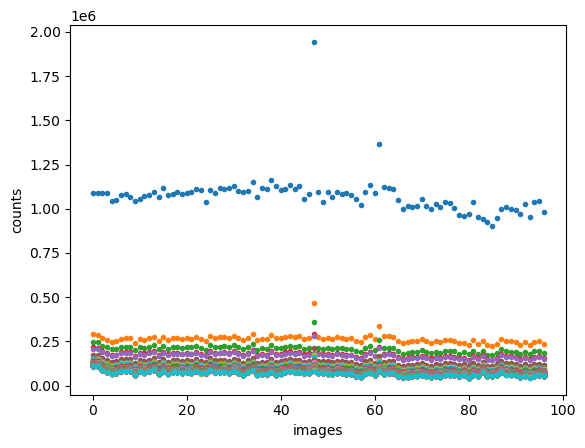

In [32]:
import matplotlib.pyplot as plt

#plot some random photometry data
for i in range(n_stars):
    plt.plot(data["fluxes"][:, i, 20], ".")
plt.xlabel("images")
_ = plt.ylabel("counts")


Target index is 76
[2367.8559786   997.65345923]
<SkyCoord (ICRS): (ra, dec) in deg
    (271.71593416, 69.82318181)>
<SkyCoord (ICRS): (ra, dec) in deg
    (271.71116788, 69.82447489)>


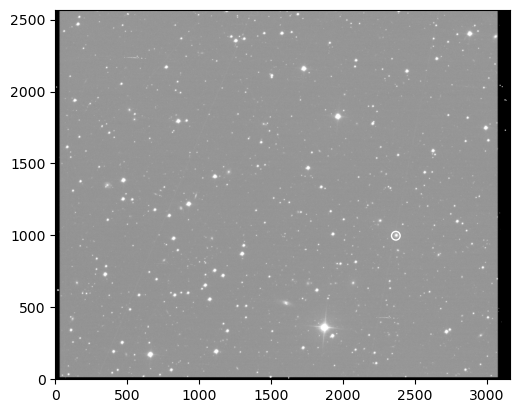

In [33]:
# need to identify the target!
from astroquery.mast import Mast
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS


#transform ref_coords to skycoords
wcs = WCS(ref_header)
centroid_radec = wcs.pixel_to_world(*ref_coords.T)

mast = Mast()
target_radec = mast.resolve_object(target_name)
target_index = int(target_radec.match_to_catalog_sky(centroid_radec)[0])

print(f"Target index is {target_index}")
print(f"{ref_coords[target_index]}")
print(f"{centroid_radec[target_index]}")
print(f"{target_radec}")

# plt.imshow(viz.z_scale(ref_data), cmap="Greys_r", origin="lower")
# viz.plot_marks(ref_coords[target_index][0],ref_coords[target_index][1], color="w", ms=30)
plt.imshow(z_scale(ref_data), cmap="Greys_r", origin="lower")
plot_marks(ref_coords[target_index], color="w", ms=30)

target = ref_coords[target_index]


In [34]:
# from eloy import flux

# photutils has no ensemble/differential photometry (Broeg 2005) - there is
# no "vanilla photutils" replacement for it, so the primitives eloy.flux
# provided (`weights`, `diff`) and eloy.utils.binned_nanstd are ported here
# as plain numpy, with no eloy dependency.


def broeg_weights(fluxes, tolerance=1e-3, max_iteration=200):
    # replaces eloy.flux.weights
    dfluxes = fluxes / np.expand_dims(np.nanmean(fluxes, -1), -1)

    def weight_function(fluxes):
        return 1 / np.std(fluxes, axis=-1)

    i = 0
    evolution = 1e25
    lcs = None
    weights = None
    last_weights = np.zeros(dfluxes.shape[0 : len(dfluxes.shape) - 1])

    while evolution > tolerance and i < max_iteration:
        if i == 0:
            weights = weight_function(dfluxes)
            mask = np.where(~np.isfinite(weights))
        else:
            weights = weight_function(lcs)

        weights[~np.isfinite(weights)] = 0

        evolution = np.abs(
            np.nanmean(weights, axis=-1) - np.nanmean(last_weights, axis=-1)
        )

        last_weights = weights
        lcs = broeg_diff(dfluxes, weights=weights)

        i += 1

    weights[0, mask] = 0

    return weights[0]


def broeg_diff(fluxes, weights=None):
    # replaces eloy.flux.diff
    diff_fluxes = fluxes / np.expand_dims(np.nanmean(fluxes, -1), -1)
    if weights is not None:
        sub = np.expand_dims((~np.eye(fluxes.shape[-2]).astype(bool)).astype(int), 0)
        weighted_fluxes = diff_fluxes * np.expand_dims(weights, -1)
        artificial_light_curve = (sub @ weighted_fluxes) / np.expand_dims(
            weights @ sub[0], -1
        )
        diff_fluxes = diff_fluxes / artificial_light_curve
    return diff_fluxes


def binned_nanstd(x, bins: int = 12):
    # replaces eloy.utils.binned_nanstd
    bins = np.min([x.shape[-1], bins])
    n = x.shape[-1] // bins
    idxs = np.arange(n * bins)

    def compute(f):
        return np.nanmean(
            np.nanstd(np.array(np.split(f.take(idxs, axis=-1), n, axis=-1)), axis=-1),
            axis=0,
        )

    return compute


def auto_diff_1d(fluxes, i=None):
    # Normalize by each star's own mean, as in `diff`/`weights`.
    dfluxes = fluxes / np.expand_dims(np.nanmean(fluxes, -1), -1)
    # Continuous Broeg weights for every star (2D (star, flux) input only,
    # see `weights`'s Notes).
    # w = flux.weights(dfluxes)
    w = broeg_weights(dfluxes)

    if i is not None:
        # Rank comparison-star candidates from most to least trustworthy
        # (descending Broeg weight).
        idxs = np.argsort(w)[::-1]
        # Callable estimating white noise as the mean standard deviation
        # within short bins, robust to slower (red) residual trends.
        # white_noise = utils.binned_nanstd(dfluxes)
        white_noise = binned_nanstd(dfluxes)
        last_white_noise = 1e10  # sentinel: worse than any real value

        def best_weights(j):
            # Keep only the top-j ranked comparison stars (by weight),
            # zeroing out the rest, and always exclude the target star
            # itself from its own comparison ensemble.
            _w = w.copy()
            _w[idxs[j::]] = 0.0
            _w[i] = 0.0
            return _w

        # Greedily grow the comparison ensemble, best star first, stopping
        # as soon as adding the next star stops helping the target's noise.
        for j in range(w.shape[-1]):
            _w = best_weights(j)
            # _df = flux.diff(dfluxes, _w)
            _df = broeg_diff(dfluxes, _w)
            # `_df` carries the extra leading singleton axis described in
            # `diff`'s Notes; select the target star's white noise and
            # unwrap that axis with the trailing [0].
            _white_noise = np.take(white_noise(_df), i, axis=-1)[0]
            if not np.isfinite(_white_noise):
                # Happens e.g. for j == 0 when no comparison star is
                # included yet (division by a degenerate/zero ensemble).
                continue
            if _white_noise < last_white_noise:
                # Still improving: keep growing the ensemble.
                last_white_noise = _white_noise
            else:
                # Adding this (lower-ranked, noisier) comparison star made
                # things worse: stop here, the previous count was better.
                break

        # Rebuild the weights using the best ensemble size found (one step
        # back from the count that first failed to improve, or from the
        # count that stopped the loop early).
        w = best_weights(j - 1)

    # Final differential fluxes computed with the (possibly trimmed)
    # weights; reshape guards against the extra singleton axis from `diff`.
    # df = flux.diff(dfluxes, w)
    df = broeg_diff(dfluxes, w)

    return df.reshape(fluxes.shape), w



# we remove the background from the annulus aperture
fluxes = (data["fluxes"] - data["bkg"]).T
flux1d = fluxes[25]

display(flux1d.shape)
diff, weights = auto_diff_1d(flux1d, target_index)
diff


(100, 97)

/tmp/ipykernel_70840/1412719669.py:51: RuntimeWarning: invalid value encountered in divide
  artificial_light_curve = (sub @ weighted_fluxes) / np.expand_dims(
/home/adamarthurryan/micromamba/envs/jupyter/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_70840/1412719669.py:65: RuntimeWarning: Mean of empty slice
  return np.nanmean(


array([[0.99864032, 1.01908174, 1.00085059, ..., 0.99160131, 0.9921063 ,
        1.00893433],
       [0.94285686, 0.95535258, 0.94086162, ..., 0.99978039, 0.99184155,
        1.00085618],
       [0.99454426, 1.00924375, 0.99028366, ..., 1.00287045, 0.99836849,
        1.01621216],
       ...,
       [1.12444888, 1.10256547, 1.04343373, ..., 0.96900209, 0.98815925,
        1.02715425],
       [0.89049196, 1.00073481, 0.96939664, ..., 0.96752356, 1.07728647,
        0.97787058],
       [1.24118595, 1.06977492, 1.06780808, ..., 0.95166342, 1.0376561 ,
        1.00806465]], shape=(100, 97))

In [35]:
# "In order to perform differential photometry eloy implements the Broeg 2005 algorithm.""

# from eloy import flux

# photutils has no equivalent for the multi-aperture wrappers around the
# Broeg algorithm either (`auto_diff`, `optimal_flux`), so they are ported
# here as plain numpy too, reusing the `broeg_diff`/`auto_diff_1d`
# primitives defined above.


def auto_diff(fluxes, i=None):
    # replaces eloy.flux.auto_diff
    if fluxes.ndim == 3:
        auto_diffs = [auto_diff_1d(f, i) for f in fluxes]
        w = [a[1] for a in auto_diffs]
        fluxes = np.array([a[0] for a in auto_diffs])
        return fluxes, np.array(w)
    else:
        return auto_diff_1d(fluxes, i)


def std_diff_metric(fluxes):
    # replaces eloy.utils.std_diff_metric
    k = len(list(np.shape(fluxes)))
    return np.std(np.diff(fluxes, axis=k - 1), axis=k - 1)


def stability_aperture(fluxes):
    # replaces eloy.utils.stability_aperture
    lc_c = np.abs(np.diff(fluxes, axis=0))
    return np.mean(lc_c, axis=1)


def optimal_flux(diff_fluxes, method="stddiff", sigma=4):
    # replaces eloy.flux.optimal_flux
    fluxes = diff_fluxes.copy()
    fluxes = fluxes[
        ...,
        np.all(
            (fluxes - np.median(fluxes, 1)[..., None])
            < sigma * np.std(fluxes, 1)[..., None],
            0,
        ),
    ]
    if method == "binned":
        white_noise = binned_nanstd(fluxes)
        criterion = white_noise(fluxes)
    elif method == "stddiff":
        criterion = std_diff_metric(fluxes)
    elif method == "stability":
        criterion = stability_aperture(fluxes)
    else:
        raise ValueError("{} is not a valid method".format(method))

    return np.argmin(criterion)


# we remove the background from the annulus aperture
fluxes = (data["fluxes"] - data["bkg"]).T

display(fluxes.shape)
'''
# and perform different photometry
# diffs, weights = flux.auto_diff(fluxes, target_index)
diffs, weights = auto_diff(fluxes, target_index)

# finally we find the 'optimal' aperture for our target
# best_aperture = flux.optimal_flux(diffs[:, target_index])
best_aperture = optimal_flux(diffs[:, target_index])
diff = diffs[best_aperture, target_index]
'''

# diffs, weights = flux.auto_diff_1d(fluxes[20], target_index)
diffs, weights = auto_diff_1d(fluxes[20], target_index)
diff=diffs[target_index]
best_aperture = 2.5
display(diff)

(40, 100, 97)

/tmp/ipykernel_70840/1412719669.py:51: RuntimeWarning: invalid value encountered in divide
  artificial_light_curve = (sub @ weighted_fluxes) / np.expand_dims(
/tmp/ipykernel_70840/1412719669.py:65: RuntimeWarning: Mean of empty slice
  return np.nanmean(


array([1.05626052, 1.10372285, 0.97971658, 1.00000737, 0.98763457,
       1.00328774, 1.03980366, 0.98252091, 1.03661793, 1.02490084,
       1.01941752, 1.01933183, 1.02955303, 1.04382275, 0.98876231,
       1.05748387, 0.98701408, 1.02935358, 1.01922104, 1.01891388,
       1.0563712 , 0.97105091, 1.08010468, 1.00982635, 1.00489534,
       1.04711173, 0.97120011, 1.00370523, 1.01214948, 0.98877434,
       1.02403295, 1.00987418, 0.97540395, 1.01470802, 1.02747016,
       0.98989685, 1.00930867, 0.9930044 , 1.04921804, 1.04563163,
       1.01244618, 1.02454705, 1.00815369, 1.01525682, 1.01396615,
       1.00206006, 0.99138428, 1.01929924, 0.99362562, 1.03684228,
       1.00603103, 0.99517093, 1.03627604, 0.99103978, 0.98758182,
       0.98811841, 0.946485  , 0.94850999, 1.01627782, 1.00764988,
       0.99701362, 1.01545945, 1.02477463, 0.99945091, 1.01417344,
       0.9520785 , 0.93578323, 0.96868318, 0.97602272, 0.994969  ,
       0.97356857, 0.99462076, 0.95122815, 0.98490471, 0.96557

In [25]:
# replaces eloy.utils.index_binning: no photutils/numpy built-in for this,
# so it's ported here as a plain function (no eloy dependency)
def index_binning(x, size):
    if isinstance(size, float):
        bins = np.arange(np.min(x), np.max(x), size)
    else:
        x = np.arange(0, len(x))
        bins = np.arange(0.0, len(x), size)

    d = np.digitize(x, bins)
    n = np.max(d) + 2
    indexes = []

    for i in range(0, n):
        s = np.where(d == i)
        if len(s[0]) > 0:
            s = s[0]
            indexes.append(s)

    return indexes


display(data["time"])
# utils.index_binning(data["time"], 0.005)
index_binning(data["time"], 0.005)

array([2461207.69516485, 2461207.69561022, 2461207.69609491,
       2461207.69654102, 2461207.69700623, 2461207.69747038,
       2461207.69796122, 2461207.69847969, 2461207.69897935,
       2461207.69950573])

[array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])]

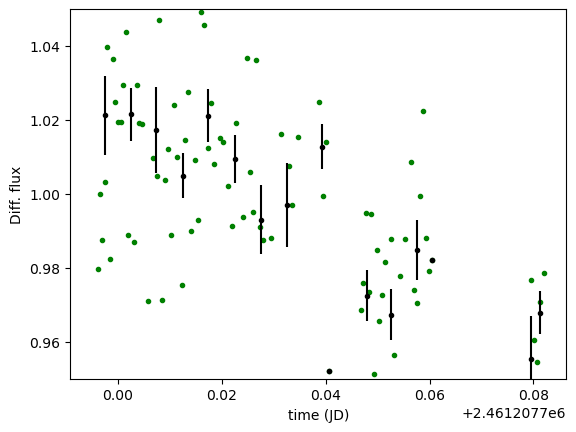

In [36]:
# idxs = utils.index_binning(data["time"], 0.005)
idxs = index_binning(data["time"], 0.005)
binned_time = [data["time"][i].mean() for i in idxs]
binned_diff = [diff[i].mean() for i in idxs]
binned_error = [diff[i].std() / np.sqrt(len(i)) for i in idxs]


#plt.plot(data["time"], diffs[best_aperture, target_index, :], ".", c="0.8")
plt.plot(data["time"], diff, ".", c="g")
plt.errorbar(binned_time, binned_diff, yerr=binned_error, fmt=".", c="k")
plt.ylim(0.95, 1.05)
plt.xlabel("time (JD)")
_ = plt.ylabel("Diff. flux")


In [11]:
print(fluxes)

[[[2.01548032e+02 2.91356146e+02 3.26253933e+02 ... 1.06209936e+02
   8.36009626e+01 3.51414045e+01]
  [2.61658236e+04 2.66586785e+04 2.78549132e+04 ... 1.16858483e+04
   9.09765589e+03 1.15868706e+04]
  [2.06598572e+04 2.38102108e+04 2.58784053e+04 ... 8.02521867e+03
   8.98575499e+03 8.97590951e+03]
  ...
  [7.21362125e+02 6.76117808e+02 5.91318109e+02 ... 2.85116055e+02
   2.79342044e+02 3.07277618e+02]
  [5.57198036e+02 6.50311698e+02 7.30990315e+02 ... 2.26089384e+02
   2.18143014e+02 2.07964197e+02]
  [6.26940750e+02 5.16238481e+02 5.59218033e+02 ... 2.54284112e+02
   2.40822184e+02 2.67589290e+02]]

 [[1.16945435e+03 1.49424297e+03 1.75811944e+03 ... 5.29745204e+02
   4.17479422e+02 1.58020625e+02]
  [1.30829224e+05 1.22422454e+05 1.37252500e+05 ... 5.01066437e+04
   4.74203263e+04 5.10454887e+04]
  [1.02977459e+05 1.13511324e+05 1.25646064e+05 ... 4.08920139e+04
   4.69632406e+04 4.77961681e+04]
  ...
  [3.41011937e+03 3.35791160e+03 2.92929518e+03 ... 1.31393916e+03
   1.29428